# XGBoost — Baseline
Treino em 2020–2023, teste em 2024. Sem SMOTE — desbalanceamento tratado via `scale_pos_weight`.
XGBoost lida com NaN nativamente; ALRM_*/GRAV_* preenchidos com 0 (ausência informativa).
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

BASE_DIR     = '../../data/features/baseline'
OUTPUT_MOD   = '../../output/modelos'
OUTPUT_MET   = '../../output/metricas'
ALGO         = 'xgboost'
DATASET      = 'baseline'
RANDOM_STATE = 42
YEAR_COL     = 'year'

## 1. Carregamento dos dados

In [2]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

mask    = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

# scale_pos_weight = n_negativos / n_positivos — equivalente ao class_weight='balanced'
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = round(n_neg / n_pos, 2)

print(f'X_train: {X_train.shape} | Óbitos: {n_pos:,} ({y_train.mean()*100:.2f}%)')
print(f'X_test:  {X_test.shape}  | Óbitos: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')
print(f'scale_pos_weight: {scale_pos_weight}')

X_train: (149544, 52) | Óbitos: 2,625 (1.76%)
X_test:  (160534, 52)  | Óbitos: 5,295 (3.30%)
scale_pos_weight: 55.97


## 2. Pipeline

In [3]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]

preprocessor = ColumnTransformer(
    transformers=[
        # Ausência informativa: NaN → 0
        ('alrm_grav',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS + GRAV_COLS),

        # CS_SEXO: F→0 / M→1 / desconhecido→-1
        ('sexo',
         OrdinalEncoder(categories=[['F', 'M']],
                        handle_unknown='use_encoded_value',
                        unknown_value=-1),
         ['CS_SEXO']),

        # SG_UF: encode ordinal
        ('uf',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['SG_UF']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        eval_metric='logloss',
    )),
])

print('Pipeline definido.')

Pipeline definido.


## 3. Treinamento

In [4]:
def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

X_train_prep = prep_X(X_train)
X_test_prep  = prep_X(X_test)

pipeline.fit(X_train_prep, y_train)
print('Treinamento concluído.')

Treinamento concluído.


## 4. Avaliação

=== XGBoost — Baseline (2020–2023 → 2024) ===
  sensibilidade: 0.7505
  especificidade: 0.9087
  auprc: 0.6113
  roc_auc: 0.9075
  f1: 0.339
  precisao: 0.219
  threshold: 0.5
  n_train: 149544
  n_obito_train: 2625

              precision    recall  f1-score   support

        Cura       0.99      0.91      0.95    155239
       Óbito       0.22      0.75      0.34      5295

    accuracy                           0.90    160534
   macro avg       0.60      0.83      0.64    160534
weighted avg       0.97      0.90      0.93    160534



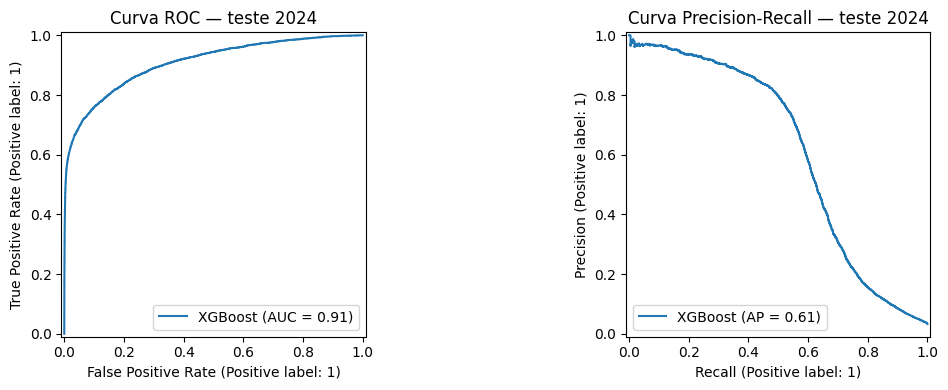

In [5]:
y_te  = y_test.dropna()
proba = pipeline.predict_proba(X_test_prep)[:, 1]
proba = proba[y_test.notna().values]

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
        'n_train':        len(X_train_prep),
        'n_obito_train':  int(y_train.sum()),
    }

metricas = calcular_metricas(y_te, proba)
print('=== XGBoost — Baseline (2020–2023 → 2024) ===')
for k, v in metricas.items():
    print(f'  {k}: {v}')

print()
print(classification_report(y_te, (proba >= 0.5).astype(int), target_names=['Cura', 'Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba, ax=axes[0], name='XGBoost')
axes[0].set_title('Curva ROC — teste 2024')
PrecisionRecallDisplay.from_predictions(y_te, proba, ax=axes[1], name='XGBoost')
axes[1].set_title('Curva Precision-Recall — teste 2024')
plt.tight_layout()
plt.show()

## 5. Matriz de Confusão (threshold = 0.5)

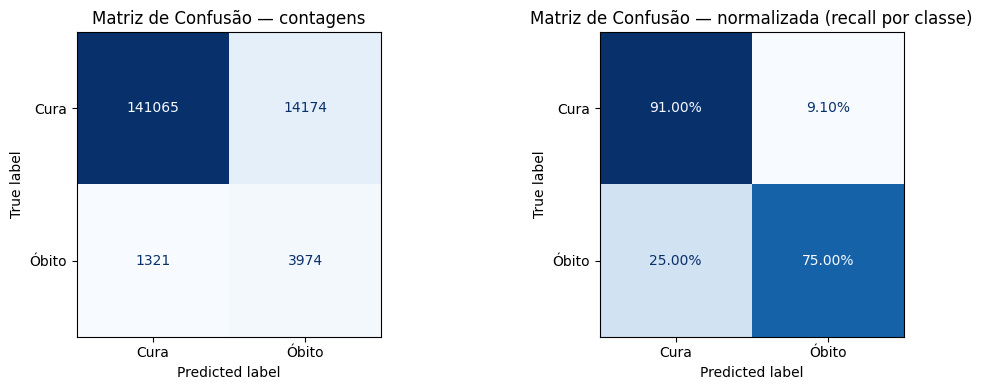

VP (óbitos detectados):   3,974
FN (óbitos perdidos):     1,321
FP (falsos alarmes):      14,174
VN (curas classificadas): 141,065


In [6]:
y_pred_05 = (proba >= 0.5).astype(int)
cm        = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada (recall por classe)')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 6. Análise de threshold

Threshold padrão  (0.50): sens=0.7505 | esp=0.9087
Threshold Youden  (0.50): sens=0.7505 | esp=0.9087
Threshold sens≥90% (0.15): sens=0.9173 | esp=0.6162


,threshold,sensibilidade,especificidade,precisao,f1,tp,fp,fn,tn
0,0.05,0.9711,0.3497,0.0485,0.0923,5142,100957,153,54282
1,0.10,0.9413,0.5133,0.0619,0.1161,4984,75552,311,79687
2,0.15,0.9173,0.6162,0.0754,0.1393,4857,59580,438,95659
3,0.20,0.8933,0.6913,0.0898,0.1632,4730,47925,565,107314
4,0.25,0.8672,0.7483,0.1052,0.1876,4592,39070,703,116169
5,0.30,0.8434,0.7930,0.1220,0.2132,4466,32134,829,123105
6,0.35,0.8181,0.8300,0.1410,0.2405,4332,26395,963,128844
7,0.40,0.7923,0.8611,0.1629,0.2702,4195,21562,1100,133677
8,0.45,0.7696,0.8874,0.1890,0.3035,4075,17487,1220,137752
9,0.50,0.7505,0.9087,0.2190,0.3390,3974,14174,1321,141065


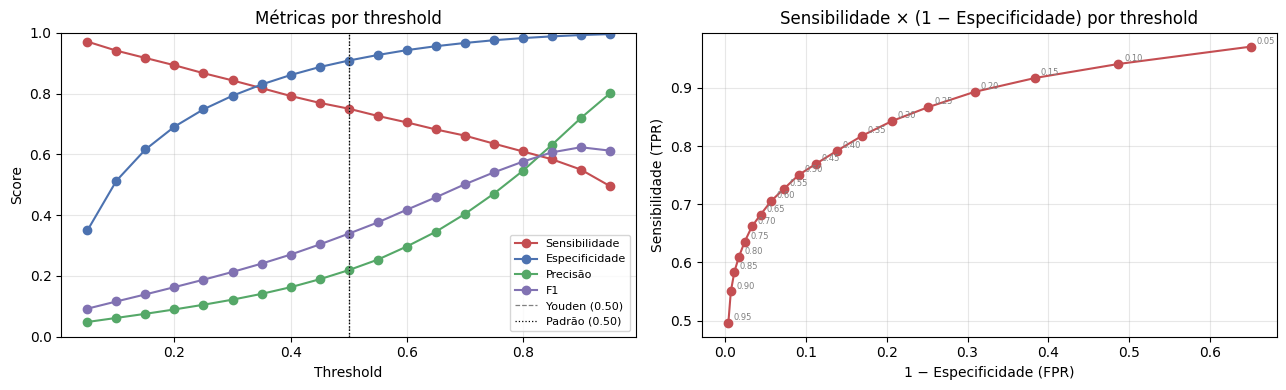

In [7]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    y_pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'threshold':      round(t, 2),
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'precisao':       round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
        'f1':             round(f1_score(y_te, y_pred), 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    })

df_thresh = pd.DataFrame(rows)
df_thresh['youden'] = df_thresh['sensibilidade'] + df_thresh['especificidade'] - 1
idx_youden = df_thresh['youden'].idxmax()

high_sens = df_thresh[df_thresh['sensibilidade'] >= 0.90]
idx_90    = high_sens['especificidade'].idxmax() if not high_sens.empty else None

print(f"Threshold padrão  (0.50): sens={df_thresh.loc[df_thresh['threshold']==0.50, 'sensibilidade'].values[0]:.4f} "
      f"| esp={df_thresh.loc[df_thresh['threshold']==0.50, 'especificidade'].values[0]:.4f}")
print(f"Threshold Youden  ({df_thresh.loc[idx_youden,'threshold']:.2f}): "
      f"sens={df_thresh.loc[idx_youden,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_youden,'especificidade']:.4f}")
if idx_90 is not None:
    print(f"Threshold sens≥90% ({df_thresh.loc[idx_90,'threshold']:.2f}): "
          f"sens={df_thresh.loc[idx_90,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_90,'especificidade']:.4f}")

display(df_thresh.drop(columns='youden'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_thresh['threshold'], df_thresh['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
axes[0].plot(df_thresh['threshold'], df_thresh['especificidade'], 'o-', color='#4C72B0', label='Especificidade')
axes[0].plot(df_thresh['threshold'], df_thresh['precisao'],       'o-', color='#55A868', label='Precisão')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],             'o-', color='#8172B2', label='F1')
axes[0].axvline(df_thresh.loc[idx_youden, 'threshold'], color='gray', linestyle='--',
                linewidth=0.9, label=f'Youden ({df_thresh.loc[idx_youden,"threshold"]:.2f})')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=0.9, label='Padrão (0.50)')
axes[0].set_title('Métricas por threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(1 - df_thresh['especificidade'], df_thresh['sensibilidade'], 'o-', color='#C44E52')
for _, row in df_thresh.iterrows():
    axes[1].annotate(f"{row['threshold']:.2f}",
                     (1 - row['especificidade'], row['sensibilidade']),
                     textcoords='offset points', xytext=(4, 2), fontsize=6, color='gray')
axes[1].set_title('Sensibilidade × (1 − Especificidade) por threshold')
axes[1].set_xlabel('1 − Especificidade (FPR)')
axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Importância das features

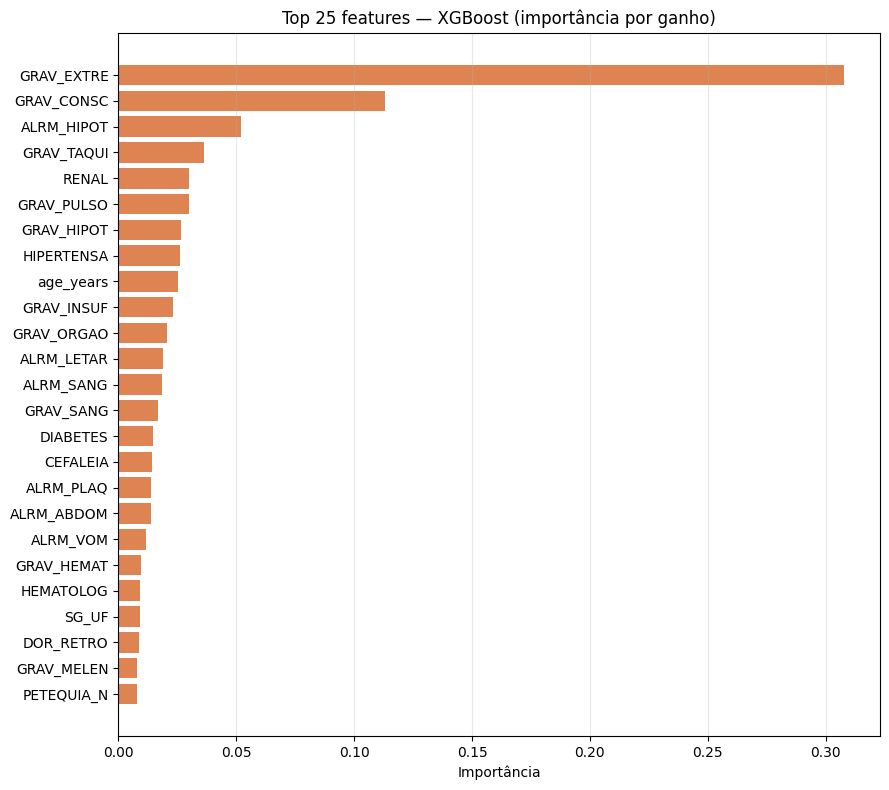

,feature,importance
14,GRAV_EXTRE,0.307659
22,GRAV_CONSC,0.113090
0,ALRM_HIPOT,0.051998
13,GRAV_TAQUI,0.036248
46,RENAL,0.030044
9,GRAV_PULSO,0.029852
15,GRAV_HIPOT,0.026601
47,HIPERTENSA,0.026111
49,age_years,0.025353
12,GRAV_INSUF,0.023364


In [8]:
feature_names = pipeline['pre'].get_feature_names_out()
importances   = pipeline['clf'].feature_importances_

df_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top_n  = 25
df_top = df_imp.head(top_n)
ax.barh(df_top['feature'][::-1], df_top['importance'][::-1], color='#DD8452')
ax.set_title(f'Top {top_n} features — XGBoost (importância por ganho)')
ax.set_xlabel('Importância')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(df_imp.head(15))

## 8. Salvamento

In [9]:
os.makedirs(OUTPUT_MOD, exist_ok=True)
os.makedirs(OUTPUT_MET, exist_ok=True)

model_path = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET}.joblib')
joblib.dump(pipeline, model_path)
print(f'Modelo salvo: {model_path}')

df_met = pd.DataFrame([metricas])
df_met['label']   = f'{ALGO}_{DATASET}'
df_met['dataset'] = DATASET
met_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}.parquet')
df_met.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba})
pred_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Modelo salvo: ../../output/modelos/xgboost_baseline.joblib
Métricas salvas: ../../output/metricas/xgboost_baseline.parquet
Predições salvas: ../../output/metricas/xgboost_baseline_predicoes.parquet


## 9. Otimização de Hiperparâmetros (GridSearchCV)
Busca exaustiva sobre `max_depth`, `learning_rate` e `min_child_weight`. `n_estimators` e `scale_pos_weight` fixos.
Avaliação por `StratifiedKFold(5)` dentro do train set (2020–2023). Scoring: `average_precision` (AUPRC).

Total: 3 × 3 × 3 = 27 combinações × 5 folds = 135 fits.

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def build_pipeline():
    return Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(
            n_estimators=500,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            eval_metric='logloss',
        )),
    ])

param_grid = {
    'clf__max_depth':        [4, 6, 8],
    'clf__learning_rate':    [0.01, 0.05, 0.1],
    'clf__min_child_weight': [1, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=build_pipeline(),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train_prep, y_train)

print(f'\nMelhores parâmetros: {grid_search.best_params_}')
print(f'Melhor AUPRC (CV):   {grid_search.best_score_:.4f}')

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv = df_cv[['param_clf__max_depth', 'param_clf__learning_rate', 'param_clf__min_child_weight',
               'mean_test_score', 'std_test_score', 'rank_test_score']]
df_cv = df_cv.sort_values('rank_test_score')
display(df_cv)

Fitting 5 folds for each of 27 candidates, totalling 135 fits



Melhores parâmetros: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__min_child_weight': 10}
Melhor AUPRC (CV):   0.6451


,param_clf__max_depth,param_clf__learning_rate,param_clf__min_child_weight,mean_test_score,std_test_score,rank_test_score
11,4,0.05,10,0.645137,0.023024,1
10,4,0.05,5,0.644647,0.024000,2
8,8,0.01,10,0.638073,0.021367,3
9,4,0.05,1,0.637816,0.025749,4
5,6,0.01,10,0.637127,0.021858,5
4,6,0.01,5,0.634924,0.023744,6
14,6,0.05,10,0.634166,0.024458,7
7,8,0.01,5,0.633343,0.022556,8
20,4,0.10,10,0.632384,0.024542,9
3,6,0.01,1,0.631500,0.018226,10


## 10. Avaliação — Modelo Tunado

=== Comparação: Baseline vs Tunado ===
Métrica              Baseline     Tunado
----------------------------------------
sensibilidade          0.7505     0.7941  (+0.0436)
especificidade         0.9087     0.8856  (-0.0231)
auprc                  0.6113     0.6291  (+0.0178)
roc_auc                0.9075     0.9175  (+0.0100)
f1                     0.3390     0.3085  (-0.0305)


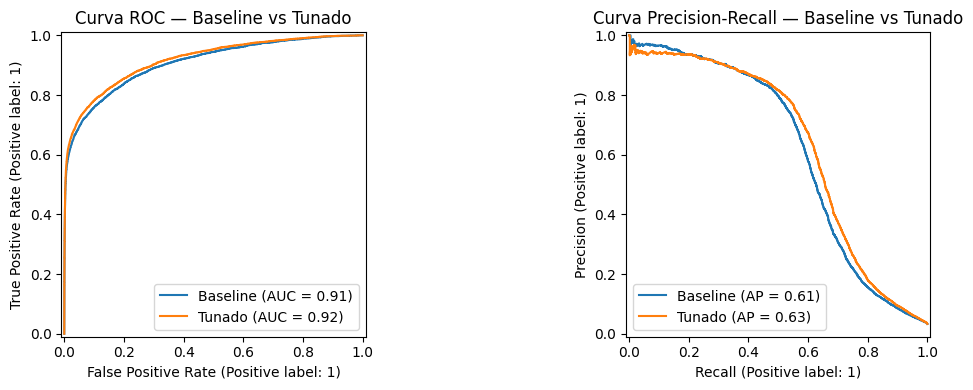

In [11]:
pipeline_tuned = grid_search.best_estimator_

proba_tuned = pipeline_tuned.predict_proba(X_test_prep)[:, 1]
proba_tuned = proba_tuned[y_test.notna().values]

metricas_tuned = calcular_metricas(y_te, proba_tuned)

print('=== Comparação: Baseline vs Tunado ===')
print(f"{'Métrica':<18} {'Baseline':>10} {'Tunado':>10}")
print('-' * 40)
for k in ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']:
    v_base  = metricas[k]
    v_tuned = metricas_tuned[k]
    diff    = v_tuned - v_base
    sinal   = '+' if diff >= 0 else ''
    print(f'{k:<18} {v_base:>10.4f} {v_tuned:>10.4f}  ({sinal}{diff:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba,       ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_te, proba_tuned, ax=axes[0], name='Tunado')
axes[0].set_title('Curva ROC — Baseline vs Tunado')

PrecisionRecallDisplay.from_predictions(y_te, proba,       ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_te, proba_tuned, ax=axes[1], name='Tunado')
axes[1].set_title('Curva Precision-Recall — Baseline vs Tunado')
plt.tight_layout()
plt.show()

## 11. Salvamento — Modelo Tunado

In [12]:
DATASET_TUNED = f'{DATASET}_tuned'

model_path_tuned = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET_TUNED}.joblib')
joblib.dump(pipeline_tuned, model_path_tuned)
print(f'Modelo salvo: {model_path_tuned}')

df_met_tuned = pd.DataFrame([metricas_tuned])
df_met_tuned['label']       = f'{ALGO}_{DATASET_TUNED}'
df_met_tuned['dataset']     = DATASET_TUNED
df_met_tuned['best_params'] = str(grid_search.best_params_)
met_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}.parquet')
df_met_tuned.to_parquet(met_path_tuned, index=False)
print(f'Métricas salvas: {met_path_tuned}')

df_pred_tuned = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_tuned})
pred_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}_predicoes.parquet')
df_pred_tuned.to_parquet(pred_path_tuned, index=False)
print(f'Predições salvas: {pred_path_tuned}')

Modelo salvo: ../../output/modelos/xgboost_baseline_tuned.joblib
Métricas salvas: ../../output/metricas/xgboost_baseline_tuned.parquet
Predições salvas: ../../output/metricas/xgboost_baseline_tuned_predicoes.parquet


## 12. Conclusão

O XGBoost **não superou** a regressão logística nas métricas prioritárias do projeto.

| Modelo               | Sensibilidade | Especificidade | AUPRC      | ROC-AUC    |
|----------------------|--------------|----------------|------------|------------|
| Logística (baseline) | **0.8004**   | 0.8853         | 0.6250     | **0.9242** |
| XGBoost (baseline)   | 0.7490       | 0.9098         | 0.6112     | 0.9098     |
| LightGBM (baseline)  | 0.6820       | 0.9520         | 0.6098     | 0.9024     |
| Random Forest        | 0.6240       | **0.9831**     | **0.6276** | 0.9209     |

**Observações:**
- O XGBoost ficou entre a regressão logística e o LightGBM — melhor sensibilidade que o LightGBM, mas ainda inferior à logística em todas as métricas prioritárias.
- O padrão se repete: modelos de árvore privilegiam especificidade em detrimento de sensibilidade neste dataset.
- AUPRC e ROC-AUC inferiores à regressão logística confirmam menor capacidade discriminativa geral.

**Modelo selecionado até o momento:** `logistic_regression_baseline`.